##Scrapping Google Apps Review - eg Mobile JKN
Week 2 NLP Pipeline PBA/ Genap 2026/ Irmasari Hafidz irma@its.ac.id

Homework: WEEK 3/ 11 maret 2026 (TUGAS 1)

Re-run google colab ini, dengan dataset apps review masing2.
Berikan analisa sederhana, dan upload di github.


In [ ]:
!pip install google_play_scraper
!pip install textblob
!pip install seaborn

In [1]:
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
# from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

# Import seaborn styles explicitly
import seaborn as sns
# Apply the seaborn style before creating plots
sns.set_style("whitegrid")  # This line sets the Seaborn style

plt.rcParams["figure.figsize"] = (15,10)

In [3]:
#Android App Mobile JKN  from Google Play at
#https://play.google.com/store/apps/details?id=app.bpjs.mobile&hl=id
#ID Apps:
#The apps ID found in the link after id=app.bpjs.mobile&hl=id
#The apps name on Google Play titled: MobileJKN dari Pemerintah Indonesia (Kemenkes)
#Dated 3 March 2025 and N of reviews 787K

from google_play_scraper import app, Sort, reviews_all

# jkn_reviews = reviews_all(
#     'app.bpjs.mobile',
#     sleep_milliseconds=0, # defaults to 0
#     lang='en', # defaults to 'en'
#     sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
# )

jkn_reviews = reviews_all(
    'com.pizzahut.phd',
    sleep_milliseconds=0, # defaults to 0
    lang='id', # defaults to 'en'
    country='id', # to identify the playstore region
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [4]:
#Save Mobile JKN reviews into dataframe
df_jknrev = pd.DataFrame(np.array(jkn_reviews),columns=['content'])
df_jknrev = df_jknrev.join(pd.DataFrame(df_jknrev.pop('content').tolist()))
df_jknrev.to_csv(r'df_jknrev', index=False)

## Homework TUGAS 1A

NLP Pipeline:
RAW data (save to csv) lakukan:

* Tokenization
* Lowering
* Stopword Removal
* Lemmatization
* Stemming
* Punctuations Removal
* Expand Contractions
* Spelling Correction
* Rare Words Removal
* Common Words Removal

(save as cleandata.csv)
* Frequent words (n=50,100,1000)
* Frequent Words found (new), contoh: yg, bs, tyt
* ditambahkan di stopwords removal
* Stopwords removal (NLTK, misal case study review hanya dalam Indonesia n=758)


In [5]:
df_jknrev

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,11b9dd91-c55a-48e2-a9af-5fc4c33d4ec3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Mau ubah alamat juga gak bisa, udah coba tetep...",1,0,NaN,2026-03-23 18:49:07,"Hi, Rizki! Kami mohon maaf atas ketidaknyamana...",2026-03-23 18:52:23,NaN
1,9a7814f6-7501-4ffd-b920-65b5ad33fc3b,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,udah mahal bnget nggk enk Toping ny asin bnget,1,0,4.2.0,2026-03-23 02:37:49,"Hi, Knzia Pptngan! Kami mohon maaf atas ketida...",2026-03-23 12:59:35,4.2.0
2,8e345657-b7ee-4ddf-840f-7ece625fafe7,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,4.2.0,2026-03-22 08:03:21,"Hi, Agus Drajad! Thank you for your review ^_^",2026-03-22 09:29:04,4.2.0
3,0658eb65-69f4-40d8-a9a4-4096a0105884,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,nah gini fitur saved address berfungsi dengan ...,5,0,NaN,2026-03-19 16:14:38,"Hi, rizky thariq! Terima kasih untuk Reviewnya...",2026-03-19 17:19:05,NaN
4,112cbb63-ac08-4b31-849c-b1fc6f9a040a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,enak cepat dan mudah,5,0,4.2.0,2026-03-18 15:22:07,"Hi, Lita Pratama! Terima kasih untuk Reviewnya...",2026-03-18 15:32:38,4.2.0
...,...,...,...,...,...,...,...,...,...,...,...
20844,cbdd77e1-19ee-4eeb-a1e8-c9dd586d1f65,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Good apps,5,5,1.0.1,2017-06-03 18:07:56,NaN,NaT,1.0.1
20845,1e283632-3159-46ee-888c-f5ceaa09c154,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,SANGAT MEMBANTU 👍,5,0,NaN,2017-06-03 17:34:43,NaN,NaT,NaN
20846,d6940af4-b3ff-4a0d-b038-30d3825a393a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Lebih praktis,5,0,NaN,2017-06-03 14:48:02,NaN,NaT,NaN
20847,bc7b4da0-73ea-41bd-973a-1e24183543f0,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,The best lah,5,2,NaN,2017-06-03 10:58:29,NaN,NaT,NaN


In [6]:
df_jknrev.info()

<class 'pandas.DataFrame'>
RangeIndex: 20849 entries, 0 to 20848
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              20849 non-null  str           
 1   userName              20849 non-null  str           
 2   userImage             20849 non-null  str           
 3   content               20849 non-null  str           
 4   score                 20849 non-null  int64         
 5   thumbsUpCount         20849 non-null  int64         
 6   reviewCreatedVersion  16806 non-null  str           
 7   at                    20849 non-null  datetime64[us]
 8   replyContent          19081 non-null  str           
 9   repliedAt             19081 non-null  datetime64[us]
 10  appVersion            16806 non-null  str           
dtypes: datetime64[us](2), int64(2), str(7)
memory usage: 1.7 MB


In [7]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column 
df_analysis = df_jknrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

In [8]:
#Check number of reviews scores
df_jknrev['score'].value_counts()

score
5    12610
1     5064
4     1325
3      931
2      919
Name: count, dtype: int64

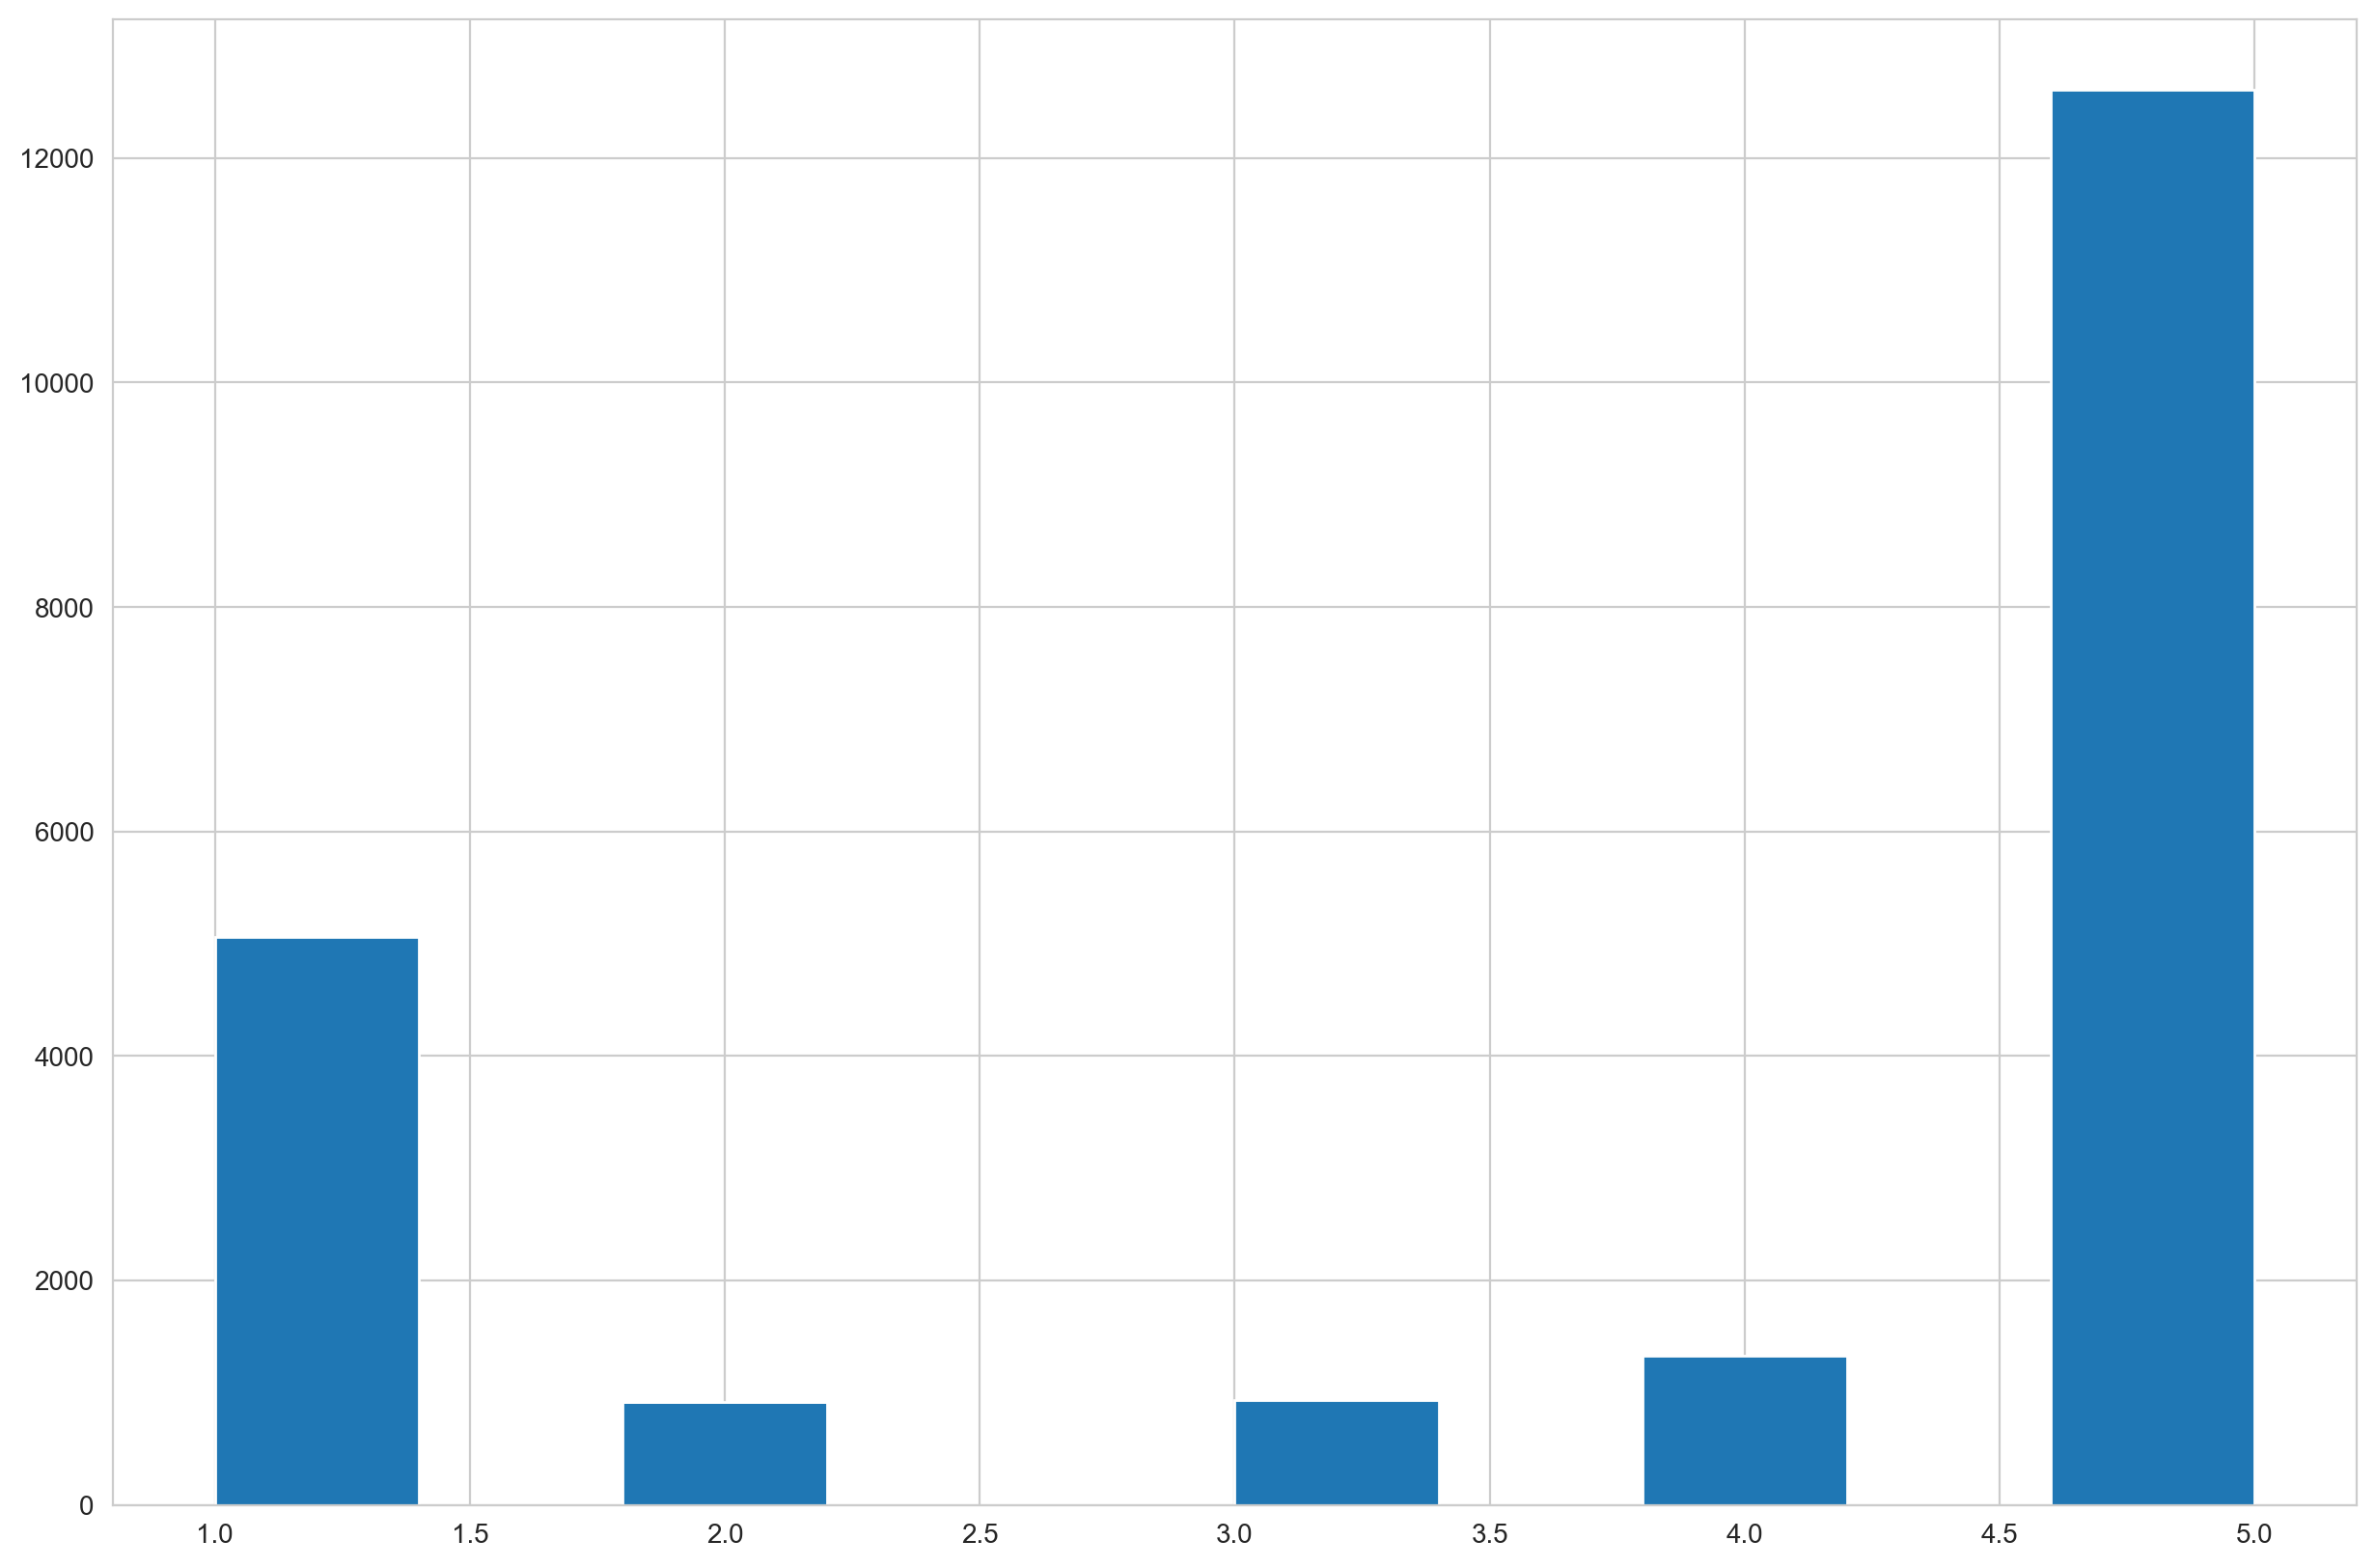

In [9]:
plt.hist(df_jknrev['score'])
plt.show()

In [11]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

In [12]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_jknrev['sentiment_polarity'] = df_jknrev['content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_jknrev['sentiment_subjective'] = df_jknrev['content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)

In [13]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,"Mau ubah alamat juga gak bisa, udah coba tetep lag di appnya",1,0.0,0.0
1,udah mahal bnget nggk enk Toping ny asin bnget,1,0.0,0.0
2,mantap,5,0.0,0.0
3,nah gini fitur saved address berfungsi dengan baik.,5,0.0,0.0
4,enak cepat dan mudah,5,0.0,0.0
...,...,...,...,...
20844,Good apps,5,0.7,0.6
20845,SANGAT MEMBANTU 👍,5,0.0,0.0
20846,Lebih praktis,5,0.0,0.0
20847,The best lah,5,1.0,0.3


## Lowercasing

In [14]:
#DATA PREPROCESSING
# Lower casing
# Change the reviews type to string
df_jknrev['content'] = df_jknrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_jknrev['content'][188])
print(df_jknrev['content'][1])
print(df_jknrev['content'][20100])

bagusss banyak freee
udah mahal bnget nggk enk Toping ny asin bnget
Semoga bermanfaat


In [15]:
#Lowercase all reviews to see the difference
df_jknrev['content']= df_jknrev['content'].apply(lambda x: x.lower())
print(df_jknrev['content'][188])
print(df_jknrev['content'][1])
print(df_jknrev['content'][20100])

bagusss banyak freee
udah mahal bnget nggk enk toping ny asin bnget
semoga bermanfaat


##Stopwords Removal
Indonesian Stopwords

In [16]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Get Indonesian stopwords
indonesian_stopwords = stopwords.words('indonesian')

# Display first 20 stopwords
print(indonesian_stopwords)



['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan'

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Frans\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_jknrev['wordCount'] = [len(review.split()) for review in df_jknrev['content']]
df_jknrev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_jknrev['content']]
df_jknrev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_jknrev['content']]

In [18]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"mau ubah alamat juga gak bisa, udah coba tetep lag di appnya",1,0.0,0.0,12,0,1
1,udah mahal bnget nggk enk toping ny asin bnget,1,0.0,0.0,9,0,0
2,mantap,5,0.0,0.0,1,0,0
3,nah gini fitur saved address berfungsi dengan baik.,5,0.0,0.0,8,0,1
4,enak cepat dan mudah,5,0.0,0.0,4,0,0
...,...,...,...,...,...,...,...
20844,good apps,5,0.7,0.6,2,0,0
20845,sangat membantu 👍,5,0.0,0.0,3,0,0
20846,lebih praktis,5,0.0,0.0,2,0,0
20847,the best lah,5,1.0,0.3,3,0,0


In [26]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_jknrev['sentiment_rating'] = df_jknrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [27]:
df_jknrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"mau ubah alamat juga gak bisa, udah coba tetep lag di appnya",1,0.0,0.0,Negative
1,udah mahal bnget nggk enk toping ny asin bnget,1,0.0,0.0,Negative
2,mantap,5,0.0,0.0,Positive
3,nah gini fitur saved address berfungsi dengan baik.,5,0.0,0.0,Positive
4,enak cepat dan mudah,5,0.0,0.0,Positive
...,...,...,...,...,...
20844,good apps,5,0.7,0.6,Positive
20845,sangat membantu 👍,5,0.0,0.0,Positive
20846,lebih praktis,5,0.0,0.0,Positive
20847,the best lah,5,1.0,0.3,Positive


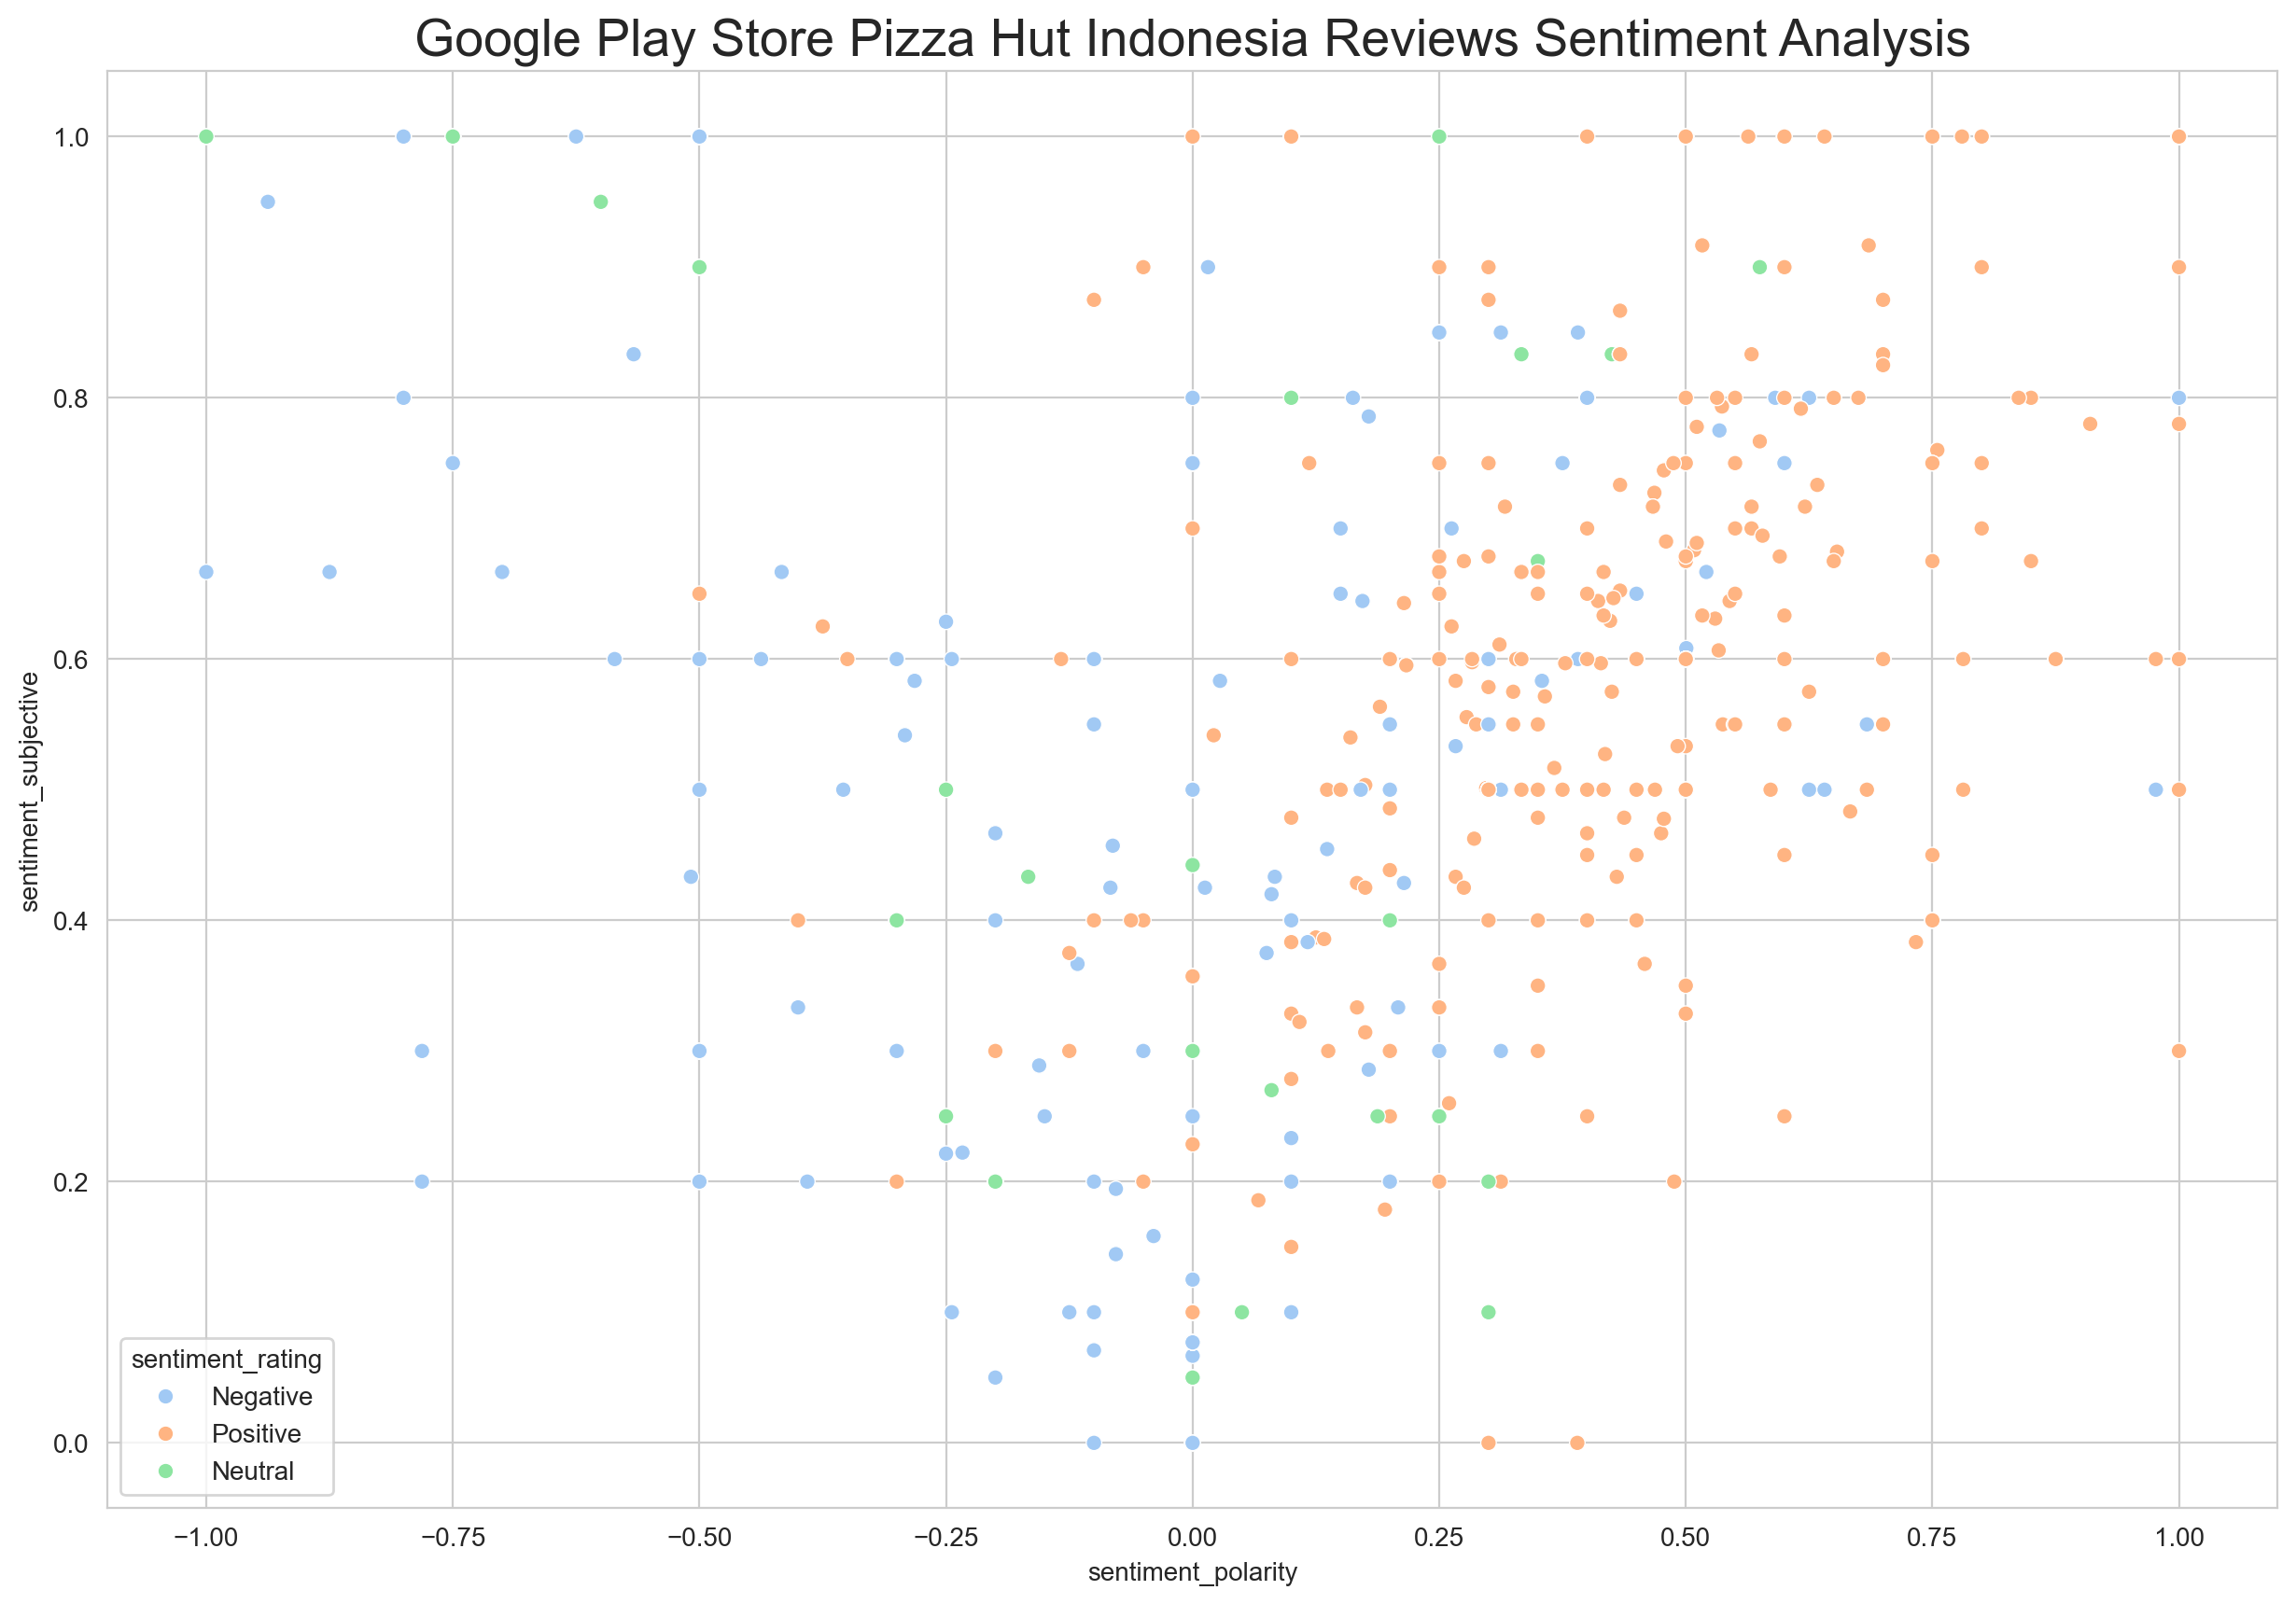

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
# Specify x and y using the 'x' and 'y' parameters within sns.scatterplot
sns.scatterplot(x=df_jknrev['sentiment_polarity'], y=df_jknrev['sentiment_subjective'],
                hue=df_jknrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Pizza Hut Indonesia Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [29]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()
  #Import FreqDist from nltk.probability
  from nltk.probability import FreqDist
  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  # Use the 'rainbow' colormap for the bar plot
  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")
  ax.set(ylabel = 'Count')
  plt.show()

In [30]:
# Sastrawi-based stopword cleaning pipeline
import re
from collections import Counter

try:
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ModuleNotFoundError:
    %pip install Sastrawi
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
sastrawi_stopwords = set(factory.get_stop_words())
stopword_remover = factory.create_stop_word_remover()

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [38]:
# Build normalized and Sastrawi-cleaned columns (keep original content untouched)
df_jknrev['content_raw'] = df_jknrev['content'].astype(str)
df_jknrev['content_norm'] = df_jknrev['content_raw'].apply(normalize_text)
df_jknrev['content_sastrawi'] = df_jknrev['content_norm'].apply(stopword_remover.remove)

tokens_after_sastrawi = " ".join(df_jknrev['content_sastrawi']).split()
top200_after_sastrawi = pd.DataFrame(
    Counter(tokens_after_sastrawi).most_common(200),
    columns=['word', 'count']
 )
top200_after_sastrawi.index = top200_after_sastrawi.index + 1

print("Top 200 words after Sastrawi stopword removal:")
print(top200_after_sastrawi.to_string())

Top 200 words after Sastrawi stopword removal:
             word  count
1        aplikasi   3009
2             nya   2523
3           pizza   2151
4              ga   1938
5             mau   1713
6             gak   1620
7          sangat   1601
8            good   1312
9              yg   1301
10         mantap   1221
11          bagus   1195
12            aja   1107
13            phd   1073
14          order   1051
15          pesan   1050
16          cepat   1015
17          mudah    963
18          login    948
19         banget    944
20           udah    870
21          lebih    866
22          promo    837
23            hut    825
24    aplikasinya    811
25       membantu    782
26         banyak    770
27          susah    760
28          masuk    736
29           buat    723
30            jam    707
31           bisa    695
32             di    688
33        pesanan    684
34           jadi    682
35       delivery    665
36        padahal    662
37            otp    635
38 

In [ ]:
# # Remove Indonesian stopwords and find top 100 remaining words
# import nltk
# from nltk.corpus import stopwords
# from nltk.probability import FreqDist
# import re

# # Get Indonesian stopwords
# indonesian_stopwords = set(stopwords.words('indonesian'))

# # Function to remove stopwords and punctuation from a single review
# def remove_stopwords(text):
#     # Remove punctuation and special characters
#     text = re.sub(r'[^\w\s]', '', str(text))
#     words = text.split()
#     filtered = [w for w in words if w.lower() not in indonesian_stopwords and len(w) > 1]
#     return ' '.join(filtered)

# # Apply stopword removal to all reviews
# df_jknrev['content_no_stopwords'] = df_jknrev['content'].apply(remove_stopwords)

# # Combine all cleaned reviews into one big string, split into words
# all_words = ' '.join(df_jknrev['content_no_stopwords']).split()

# # Calculate word frequencies
# fdist = FreqDist(all_words)

# # Get the top 100 words after stopword removal
# top100 = fdist.most_common(200)

# # Display them in a nice table
# top100_df = pd.DataFrame(top100, columns=['word', 'count'])
# top100_df.index = top100_df.index + 1  # Start index from 1
# print("=== Top 100 Words After Indonesian Stopword Removal ===\n")
# print(top100_df.to_string())


=== Top 100 Words After Indonesian Stopword Removal ===

             word  count
1        aplikasi   2963
2             nya   2385
3           pizza   2098
4              ga   1916
5             gak   1601
6              yg   1293
7            good   1292
8          mantap   1189
9           bagus   1162
10            aja   1093
11            phd   1034
12          pesan   1024
13          order   1013
14          cepat    956
15          mudah    928
16         banget    920
17          login    920
18             ok    867
19           udah    843
20            hut    810
21    aplikasinya    786
22          promo    779
23             ya    773
24       membantu    762
25          susah    738
26        pesanan    667
27            jam    661
28       delivery    647
29          masuk    645
30            otp    620
31      pelayanan    601
32            app    593
33             gk    529
34           pake    528
35         daftar    520
36          ribet    512
37          bikin 

In [40]:
# Manually add frequent words you want to remove after reviewing top200_after_sastrawi
manual_stopwords = [
    "aplikasi",
    "aplikasinya",
    "nya",
    "pizza",
    "phd",
    "hut",
    "yg",
    "aja",
    "order",
    "pesan",
    "pesanan",
    "pesen",
    "app",
    "apk",
    "ga",
    "gak",
    "gk",
    "g",
    "mau",
    "udah",
    "udh",
    "dah",
    "sdh",
    "sudah",
    "jadi",
    "jd",
    "buat",
    "bisa",
    "bs",
    "di",
    "ada",
    "ad",
    "kalo",
    "kalau",
    "klo",
    "tp",
    "tapi",
    "sih",
    "kok",
    "deh",
    "nih",
    "dong",
    "lah",
    "sama",
    "pas",
    "apa",
    "kali",
    "dulu",
    "d",
    "ke",
    "saya",
    "sy",
    "aku",
    "via",
    "in",
    "the",
    "no",
    "x",
    "dr",
    "dari",
    "utk",
    "untuk",
    "jg",
    "juga",
    "aja",
    "aj",
    "mulu",
    "masa",
    "pake",
    "pakai",
    "banget",
    "bgt",
    "emang",
    "padahal",
    "malah",
    "terus",
    "trus",
    "langsung",
    "cuma",
    "banyak",
    "tetap",
    "tetep",
    "hanya",
    "biar",
    "sangat",
    "sekali",
    "banget",
    "tambah"
]

manual_stopwords = set(
    w.strip().lower() for w in manual_stopwords
    if isinstance(w, str) and w.strip()
 )

print(f"Manual stopwords count: {len(manual_stopwords)}")
print(sorted(list(manual_stopwords))[:30])

Manual stopwords count: 86
['ad', 'ada', 'aj', 'aja', 'aku', 'apa', 'apk', 'aplikasi', 'aplikasinya', 'app', 'banget', 'banyak', 'bgt', 'biar', 'bisa', 'bs', 'buat', 'cuma', 'd', 'dah', 'dari', 'deh', 'di', 'dong', 'dr', 'dulu', 'emang', 'g', 'ga', 'gak']


In [41]:
# Apply manual stopword filtering on top of Sastrawi result
def remove_manual_stopwords(text, stopword_set):
    tokens = str(text).split()
    filtered = [t for t in tokens if t.lower() not in stopword_set]
    return " ".join(filtered)

df_jknrev['content_clean_final'] = df_jknrev['content_sastrawi'].apply(
    lambda x: remove_manual_stopwords(x, manual_stopwords)
 )

df_jknrev[['content_raw', 'content_sastrawi', 'content_clean_final']].head(5)

,content_raw,content_sastrawi,content_clean_final
0,"mau ubah alamat juga gak bisa, udah coba tetep lag di appnya",mau ubah alamat gak udah coba tetep lag appnya,ubah alamat coba lag appnya
1,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,mahal bnget nggk enk toping ny asin bnget
2,mantap,mantap,mantap
3,nah gini fitur saved address berfungsi dengan baik.,nah gini fitur saved address berfungsi baik,nah gini fitur saved address berfungsi baik
4,enak cepat dan mudah,enak cepat mudah,enak cepat mudah


In [42]:
# Recompute top 200 words after manual stopword removal
tokens_after_manual = " ".join(df_jknrev['content_clean_final']).split()
top200_after_manual = pd.DataFrame(
    Counter(tokens_after_manual).most_common(200),
    columns=['word', 'count']
 )
top200_after_manual.index = top200_after_manual.index + 1

print("Top 30 words after Sastrawi + manual stopword removal:")
top200_after_manual.head(30)

Top 30 words after Sastrawi + manual stopword removal:


,word,count
1,good,1312
2,mantap,1221
3,bagus,1195
4,cepat,1015
5,mudah,963
6,login,948
7,lebih,866
8,promo,837
9,membantu,782
10,susah,760


In [43]:
# Compare text at each cleaning stage
df_jknrev.loc[:, [
    'content_raw',
    'content_sastrawi',
    'content_clean_final',
    'score',
    'sentiment_polarity',
    'sentiment_subjective',
    'sentiment_rating'
 ]].head(10)

,content_raw,content_sastrawi,content_clean_final,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"mau ubah alamat juga gak bisa, udah coba tetep lag di appnya",mau ubah alamat gak udah coba tetep lag appnya,ubah alamat coba lag appnya,1,0.0,0.0,Negative
1,udah mahal bnget nggk enk toping ny asin bnget,udah mahal bnget nggk enk toping ny asin bnget,mahal bnget nggk enk toping ny asin bnget,1,0.0,0.0,Negative
2,mantap,mantap,mantap,5,0.0,0.0,Positive
3,nah gini fitur saved address berfungsi dengan baik.,nah gini fitur saved address berfungsi baik,nah gini fitur saved address berfungsi baik,5,0.0,0.0,Positive
4,enak cepat dan mudah,enak cepat mudah,enak cepat mudah,5,0.0,0.0,Positive
5,lebih murah dan nyaman pesan di aplikasi,lebih murah nyaman pesan aplikasi,lebih murah nyaman,5,0.0,0.0,Positive
6,mantap,mantap,mantap,5,0.0,0.0,Positive
7,"pelayanan ramah,, sukses selalu...",pelayanan ramah sukses selalu,pelayanan ramah sukses selalu,5,0.0,0.0,Positive
8,baik,baik,baik,5,0.0,0.0,Positive
9,good.resto paporiuut,good resto paporiuut,good resto paporiuut,5,0.0,0.0,Positive


In [44]:
# Show words that disappeared from top-200 after manual filtering
removed_from_top200 = sorted(
    set(top200_after_sastrawi['word']) - set(top200_after_manual['word'])
)

print(f"Words removed from top-200 after manual filtering: {len(removed_from_top200)}")
removed_from_top200[:50]

Words removed from top-200 after manual filtering: 76


['ada',
 'aja',
 'aku',
 'apa',
 'apk',
 'aplikasi',
 'aplikasinya',
 'app',
 'banget',
 'banyak',
 'bgt',
 'biar',
 'bisa',
 'bs',
 'buat',
 'cuma',
 'd',
 'dah',
 'deh',
 'di',
 'dong',
 'dr',
 'dulu',
 'g',
 'ga',
 'gak',
 'gk',
 'hut',
 'in',
 'jadi',
 'jd',
 'jg',
 'kalau',
 'kali',
 'kalo',
 'klo',
 'kok',
 'lah',
 'langsung',
 'malah',
 'masa',
 'mau',
 'mulu',
 'nih',
 'no',
 'nya',
 'order',
 'padahal',
 'pakai',
 'pake']

C:\Users\Frans\AppData\Local\Temp\ipykernel_89328\2152088084.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=d, x= "word", y = "count", palette="rainbow")


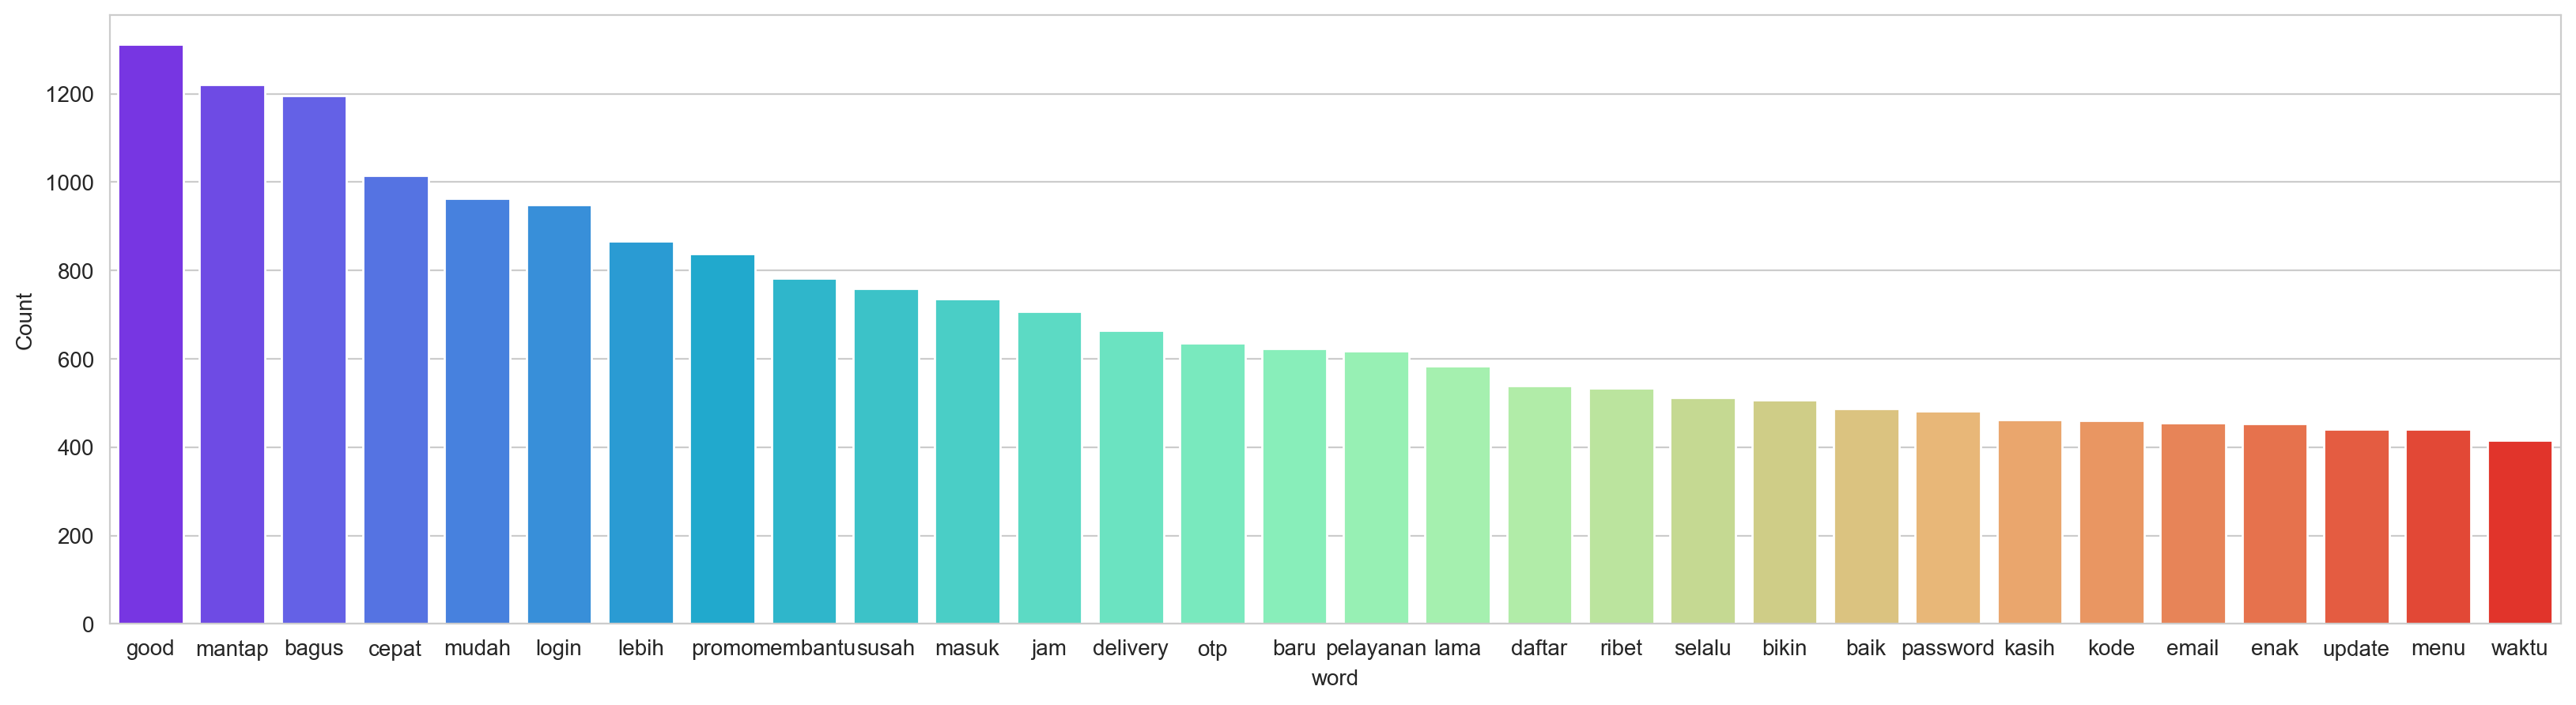

In [45]:
# Plot most frequent terms from final cleaned text
freq_words(df_jknrev['content_clean_final'], terms=30)

In [46]:
# Export cleaned result
output_path = 'df_jknrev_cleaned.csv'
df_jknrev.to_csv(output_path, index=False)
print(f"Saved cleaned dataset to: {output_path}")
print(f"Total rows: {len(df_jknrev)}")

Saved cleaned dataset to: df_jknrev_cleaned.csv
Total rows: 20849
